In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import os
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('bitcoin_selected_features.csv')

In [143]:
df.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,day
0,93186.34,94305.61,93181.83,93964.01,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07,23
1,93964.01,95191.81,93911.50,95191.81,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07,23
2,95191.80,95509.09,94683.81,94881.47,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07,23
3,94881.47,94881.47,94131.11,94550.22,955.84079,9.027902e+07,187102,449.36960,4.244027e+07,24
4,94550.23,94672.00,94036.00,94123.43,567.58156,5.354935e+07,157351,268.15219,2.530346e+07,24


In [141]:
# df["up_shadow"] = df["high"] - df["close"]
# df["low_shadow"] = df["close"] - df["low"]

# Creating 'next_first_hour_close', 'next_second_hour_close', 'next_third_hour_close', 'next_fourth_hour_close'
# df["next_first_hour_close"] = df["close"].shift(-1)
# df["next_second_hour_close"] = df["close"].shift(-2)
# df["next_third_hour_close"] = df["close"].shift(-3)
# df["next_fourth_hour_close"] = df["close"].shift(-4)

# Dropping the last 4 rows as they will have NaN values
# df = df.dropna().reset_index(drop=True)

In [144]:
df['target_close'] = df['close'].shift(-1)

In [145]:
df.isnull().sum()

open                            0
high                            0
low                             0
close                           0
volume                          0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
day                             0
target_close                    1
dtype: int64

In [146]:
df = df.dropna()

In [147]:
df = df.drop(columns=['close'], axis=1)

In [148]:
df["average_price"] = (df["high"] + df["low"]) / 2

In [149]:
df = df.drop(columns=['day'], axis=1)

In [ ]:
X = df.drop(columns=["target_close"])  
y = df["target_close"]

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
# y_test_scaled = scaler.transform(y_test.values.reshape(-1,1))

In [155]:
model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.007,
    max_depth=4,
    min_child_weight=3,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    objective='reg:squarederror',
)
model.fit(X_train_scaled, y_train)

# model = LinearRegression()

# model.fit(X_train, y_train)

y_pred = model.predict(X_test_scaled)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

In [156]:
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 503.07614218750007
Mean Squared Error (MSE): 510659.120066393
Root Mean Squared Error (RMSE): 714.6041701994139


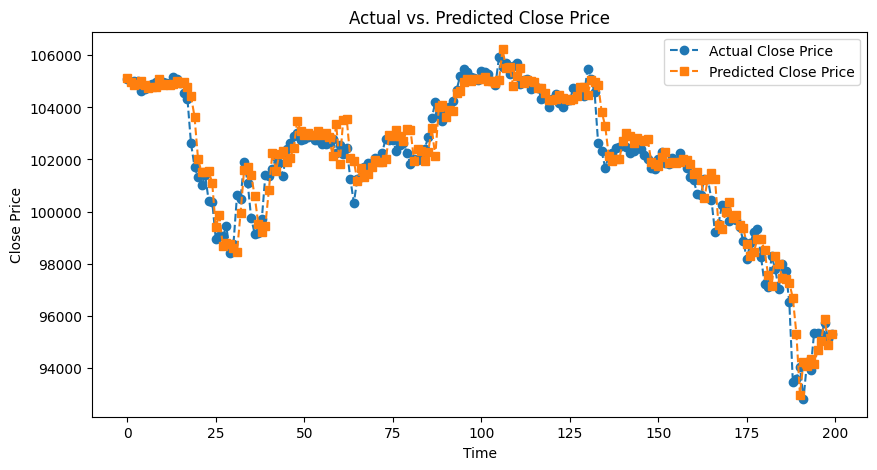

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Close Price", marker='o', linestyle='dashed')
plt.plot(y_pred, label="Predicted Close Price", marker='s', linestyle='dashed')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Actual vs. Predicted Close Price")
plt.legend()
plt.show()


<Axes: >

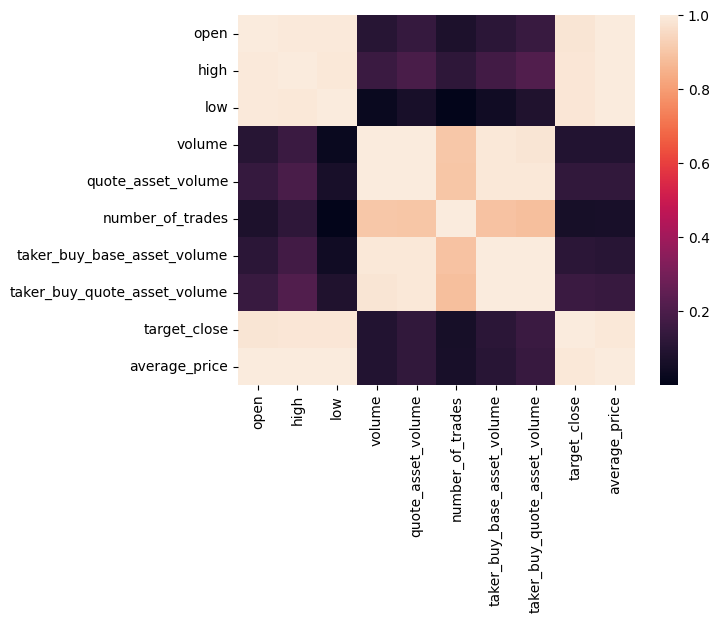

In [27]:
sns.heatmap(df.corr())